In [116]:
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import meteostat as ms

# Load data

In [117]:
# Choose station (near downtown LA). You can replace coords or fetch another station.
POINT = ms.Point(34.05, -118.24)  # Try with your location
n_stations = 20 # set a reasonable limit to avoid fetching too many stations
stations = ms.stations.nearby(POINT, limit=n_stations)  # Downtown Los Angeles coords

# Define target weeks (inclusive)
p1_start, p1_end = datetime(2016,12,12), datetime(2016,12,18)
p2_start, p2_end = datetime(2016,8,12),  datetime(2016,8,18)

In [119]:
# Check if stations have data in both time windows
def check_station_data(st_id, start, end, min_days=1, vars=['temp','wspd']):
    """Check station data availability in a date window. Returns dict and prints summary."""
    try:
        ts = ms.daily(st_id, start, end).fetch()
    except Exception as e:
        print(f"{st_id}: error fetching -> {e}")
        return {'id': st_id, 'has_data': False, 'error': str(e)}

    if ts is None or ts.empty:
        print(f"✗ Station {st_id} has NO data in Meteostat for {start}–{end}")
        return {'id': st_id, 'has_data': False, 'records': 0}

    # count days where any requested var is present
    valid_days = ts[vars].notna().any(axis=1).sum()
    print(f"✓ Station {st_id} HAS data: records={len(ts)}, valid_days={valid_days}, range={ts.index.min()} to {ts.index.max()}")
    return {'id': st_id, 'has_data': int(valid_days) >= min_days, 'records': len(ts),
            'valid_days': int(valid_days), 'range': (ts.index.min(), ts.index.max())}

print("\nNearby stations data summary:")
results = []
top_n = 10
for st in stations.index[:top_n]:
    r1 = check_station_data(st, p1_start, p1_end, min_days=4)
    r2 = check_station_data(st, p2_start, p2_end, min_days=4)

    r1_range = r1.get('range')
    r2_range = r2.get('range')

    results.append({
        'id': st,
        'p1_has': bool(r1.get('has_data')),
        'p1_valid_days': int(r1.get('valid_days', 0)),
        'p1_records': int(r1.get('records', 0)),
        'p1_start_avail': str(r1_range[0]) if r1_range else None,
        'p1_end_avail':   str(r1_range[1]) if r1_range else None,
        'p2_has': bool(r2.get('has_data')),
        'p2_valid_days': int(r2.get('valid_days', 0)),
        'p2_records': int(r2.get('records', 0)),
        'p2_start_avail': str(r2_range[0]) if r2_range else None,
        'p2_end_avail':   str(r2_range[1]) if r2_range else None,
    })

summary = pd.DataFrame(results).set_index('id')
print(f"\nNearby stations summary (top {top_n}):")
print(summary)

candidates = summary[(summary.p1_has) & (summary.p2_has)]
if not candidates.empty:
    chosen = candidates.index[0]
    print("\nChosen station with data in both windows:", chosen)
    if chosen in stations.index:
        print(stations.loc[chosen])
else:
    print(f"\nNo nearby station (top {top_n}) had >=4 valid days in both windows.")


Nearby stations data summary:
✗ Station KCQT0 has NO data in Meteostat for 2016-12-12 00:00:00–2016-12-18 00:00:00
✗ Station KCQT0 has NO data in Meteostat for 2016-08-12 00:00:00–2016-08-18 00:00:00
✓ Station KHHR0 HAS data: records=7, valid_days=7, range=2016-12-12 00:00:00 to 2016-12-18 00:00:00
✓ Station KHHR0 HAS data: records=7, valid_days=7, range=2016-08-12 00:00:00 to 2016-08-18 00:00:00
✓ Station 72295 HAS data: records=7, valid_days=7, range=2016-12-12 00:00:00 to 2016-12-18 00:00:00
✓ Station 72295 HAS data: records=7, valid_days=7, range=2016-08-12 00:00:00 to 2016-08-18 00:00:00
✗ Station KEMT0 has NO data in Meteostat for 2016-12-12 00:00:00–2016-12-18 00:00:00
✗ Station KEMT0 has NO data in Meteostat for 2016-08-12 00:00:00–2016-08-18 00:00:00
✗ Station 71D38 has NO data in Meteostat for 2016-12-12 00:00:00–2016-12-18 00:00:00
✗ Station 71D38 has NO data in Meteostat for 2016-08-12 00:00:00–2016-08-18 00:00:00
✓ Station 72288 HAS data: records=7, valid_days=7, range=20

In [120]:
# examine list of stations 
stations

,name,country,region,latitude,longitude,elevation,timezone,distance
id,,,,,,,,
KCQT0,Los Angeles / Jefferson,US,CA,34.01670,-118.28330,56,America/Los_Angeles,5443.4
KHHR0,Hawthorne / Cypave,US,CA,33.92280,-118.33520,20,America/Los_Angeles,16646.2
72295,Los Angeles Airport,US,CA,33.93330,-118.38330,38,America/Los_Angeles,18518.3
KEMT0,El Monte / Hayes,US,CA,34.08600,-118.03480,90,America/Los_Angeles,19320.4
71D38,Santa Monica Municipal Airport,US,CA,34.01583,-118.45139,53,America/Los_Angeles,19846.5
72288,Burbank-Glendale-Pasadena,US,CA,34.20000,-118.36670,236,America/Los_Angeles,20352.2
72289,Mount Wilson,US,CA,34.23330,-118.06670,1739,America/Los_Angeles,25880.4
72297,Long Beach Airport,US,CA,33.81670,-118.15000,17,America/Los_Angeles,27238.2
KWHP0,Los Angeles / Pacoima,US,CA,34.25930,-118.41340,306,America/Los_Angeles,28217.4


In [121]:
# What is the range of data available for the chosen station?
ms.config.block_large_requests = False
station_id = "72295"  # 72295 is LAX
def monthly_range(station_id, start=datetime(1900,1,1), end=None):
    end = end or datetime.now()
    try:
        df = ms.monthly(station_id, start, end).fetch()
        return str(df.index.min().date()), str(df.index.max().date())
    except Exception:
        return None, None

print(monthly_range(station_id))

('1944-01-01', '2025-11-01')


# Compare diurnal

## Temperature 

Fetching hourly data for summer reference period (2016-08-01 to 2016-08-31)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


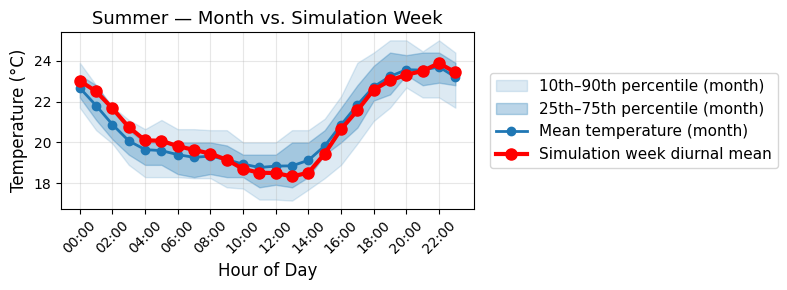

Fetching hourly data for winter reference period (2016-12-01 to 2016-12-31)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


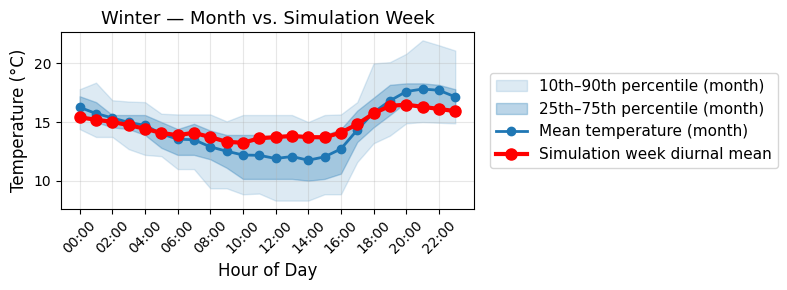

In [145]:
#  Month vs. simulation week
time_periods = {
    'summer': {
        'reference': (datetime(2016, 8, 1), datetime(2016, 8, 31)),
        'simulation': (p2_start, p2_end)
    },
    'winter': {
        'reference': (datetime(2016, 12, 1), datetime(2016, 12, 31)),
        'simulation': (p1_start, p1_end)
    }
}

for season, periods in time_periods.items():
    # Reference (full month)
    ref_start, ref_end = periods['reference']
    print(f"Fetching hourly data for {season} reference period ({ref_start.date()} to {ref_end.date()})...")
    ts_ref = ms.hourly(station_id, ref_start, ref_end).fetch()
    ts_ref['hour'] = ts_ref.index.hour
    ref_hourly = ts_ref.groupby('hour')['temp'].agg([
        'mean',
        ('p10', lambda x: x.quantile(0.10)),
        ('p25', lambda x: x.quantile(0.25)),
        ('p75', lambda x: x.quantile(0.75)),
        ('p90', lambda x: x.quantile(0.90)),
    ]).reset_index()

    # Simulation week
    sim_start, sim_end = periods['simulation']
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    ts_sim['hour'] = ts_sim.index.hour
    sim_hourly = ts_sim.groupby('hour')['temp'].mean()

    # Plot
    fig, ax = plt.subplots(figsize=(8, 3))
    hours = ref_hourly['hour'].values
    mean_temp = ref_hourly['mean'].values
    p10 = ref_hourly['p10'].values
    p25 = ref_hourly['p25'].values
    p75 = ref_hourly['p75'].values
    p90 = ref_hourly['p90'].values

    ax.fill_between(hours, p10, p90, alpha=0.15, color='C0', label='10th–90th percentile (month)')
    ax.fill_between(hours, p25, p75, alpha=0.30, color='C0', label='25th–75th percentile (month)')
    ax.plot(hours, mean_temp, 'o-', linewidth=2, markersize=6, color='C0', label='Mean temperature (month)')
    ax.plot(sim_hourly.index, sim_hourly.values, 'o-', linewidth=3, markersize=8, color='red', label='Simulation week diurnal mean')

    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Temperature (°C)', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Month vs. Simulation Week', fontsize=13)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()

Fetching hourly data for summer reference period (2016-06-01 to 2016-08-31)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


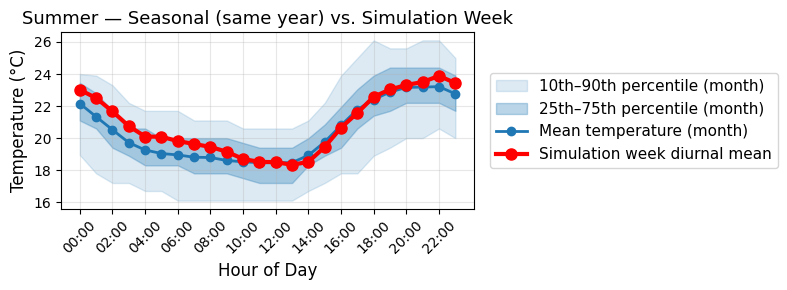

Fetching hourly data for winter reference period (2016-12-01 to 2017-02-28)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


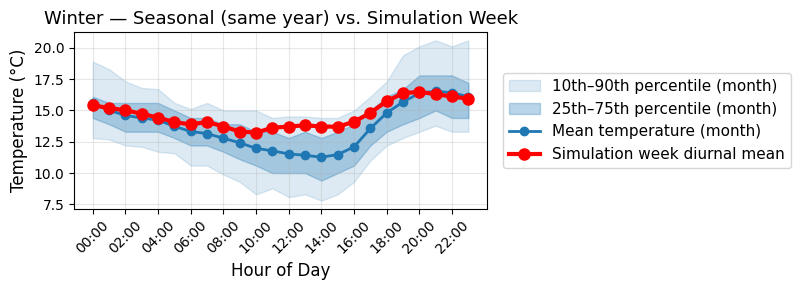

In [144]:
# Seasonal vs. simulation week
time_periods = {
    'summer': {
        'reference': (datetime(2016, 6, 1), datetime(2016, 8, 31)),
        'simulation': (p2_start, p2_end)
    },
    'winter': {
        'reference': (datetime(2016, 12, 1), datetime(2017, 2, 28)),
        'simulation': (p1_start, p1_end)
    }
}

for season, periods in time_periods.items():
    # Reference (full month)
    ref_start, ref_end = periods['reference']
    print(f"Fetching hourly data for {season} reference period ({ref_start.date()} to {ref_end.date()})...")
    ts_ref = ms.hourly(station_id, ref_start, ref_end).fetch()
    ts_ref['hour'] = ts_ref.index.hour
    ref_hourly = ts_ref.groupby('hour')['temp'].agg([
        'mean',
        ('p10', lambda x: x.quantile(0.10)),
        ('p25', lambda x: x.quantile(0.25)),
        ('p75', lambda x: x.quantile(0.75)),
        ('p90', lambda x: x.quantile(0.90)),
    ]).reset_index()

    # Simulation week
    sim_start, sim_end = periods['simulation']
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    ts_sim['hour'] = ts_sim.index.hour
    sim_hourly = ts_sim.groupby('hour')['temp'].mean()

    # Plot
    fig, ax = plt.subplots(figsize=(8, 3))
    hours = ref_hourly['hour'].values
    mean_temp = ref_hourly['mean'].values
    p10 = ref_hourly['p10'].values
    p25 = ref_hourly['p25'].values
    p75 = ref_hourly['p75'].values
    p90 = ref_hourly['p90'].values

    ax.fill_between(hours, p10, p90, alpha=0.15, color='C0', label='10th–90th percentile (month)')
    ax.fill_between(hours, p25, p75, alpha=0.30, color='C0', label='25th–75th percentile (month)')
    ax.plot(hours, mean_temp, 'o-', linewidth=2, markersize=6, color='C0', label='Mean temperature (month)')
    ax.plot(sim_hourly.index, sim_hourly.values, 'o-', linewidth=3, markersize=8, color='red', label='Simulation week diurnal mean')

    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Temperature (°C)', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Seasonal (same year) vs. Simulation Week', fontsize=13)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()

Computing 20yr climatology for summer (2016-08-12–2016-08-18)...
Fetching simulation-week data for summer (2016-08-12–2016-08-18)...


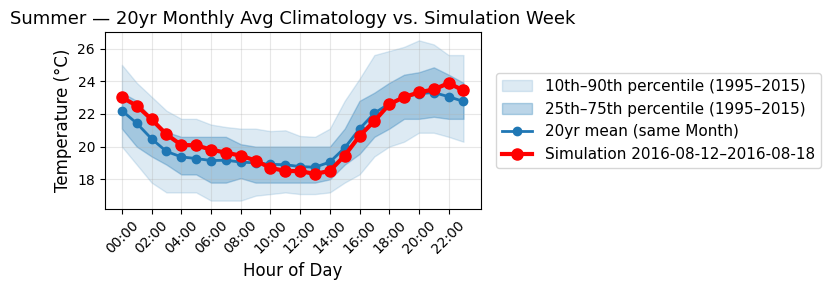

Computing 20yr climatology for winter (2016-12-12–2016-12-18)...
Fetching simulation-week data for winter (2016-12-12–2016-12-18)...


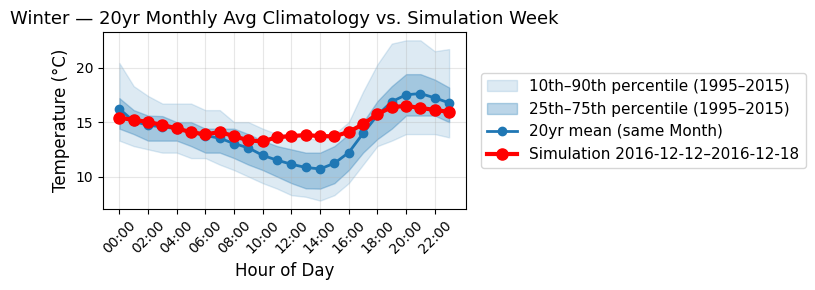

In [192]:
# climatology of correponding month vs. simulation week
yr_start = 1995
yr_end = 2015 
n_years = yr_end - yr_start
years = range(yr_start, yr_end+1) 

def climatology_for_month(station_id, start, end, years):
    rows = []
    for y in years:
        try:
            s = start.replace(year=y)
            e = end.replace(year=y)
        except ValueError:
            # skip invalid dates (e.g. Feb 29 on non-leap years)
            continue
        df = ms.hourly(station_id, s, e).fetch()
        if df is None or df.empty:
            continue
        df['hour'] = df.index.hour
        rows.append(df[['temp', 'hour']])

    if not rows:
        return None
    all_data = pd.concat(rows, axis=0)
    grouped = all_data.groupby('hour')['temp']

    return {
        'mean': grouped.mean(),
        'p10': grouped.quantile(0.10),
        'p25': grouped.quantile(0.25),
        'p75': grouped.quantile(0.75),
        'p90': grouped.quantile(0.90),
    }

for season, periods in time_periods.items():
    sim_start, sim_end = periods['simulation']
    print(f"Computing {n_years}yr climatology for {season} ({sim_start.date()}–{sim_end.date()})...")
    clim = climatology_for_month(station_id, sim_start, sim_end, years)
    if clim is None:
        print("No climatology data available for that window; skipping.")
        continue

    # fetch simulation-week hourly means
    print(f"Fetching simulation-week data for {season} ({sim_start.date()}–{sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    ts_sim['hour'] = ts_sim.index.hour
    sim_hourly = ts_sim.groupby('hour')['temp'].mean().reindex(range(24))

    # plot (legend placed to the right)
    hours = np.arange(24)
    fig, ax = plt.subplots(figsize=(8, 3))  # wider to make room for legend

    ax.fill_between(hours, clim['p10'].reindex(hours).values, clim['p90'].reindex(hours).values,
                    alpha=0.15, color='C0', label=f'10th–90th percentile ({yr_start}–{yr_end})')
    ax.fill_between(hours, clim['p25'].reindex(hours).values, clim['p75'].reindex(hours).values,
                    alpha=0.30, color='C0', label=f'25th–75th percentile ({yr_start}–{yr_end})')
    ax.plot(hours, clim['mean'].reindex(hours).values, 'o-', color='C0', linewidth=2, markersize=6,
            label=f'{n_years}yr mean (same Month)')
    ax.plot(sim_hourly.index.values, sim_hourly.values, 'o-', color='red', linewidth=3, markersize=8,
            label=f'Simulation {sim_start.date()}–{sim_end.date()}')

    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Temperature (°C)', fontsize=12)
    ax.set_title(f'{season.capitalize()} — {n_years}yr Monthly Avg Climatology vs. Simulation Week', fontsize=13)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
    ax.grid(True, alpha=0.3)

    # place legend outside to the right and make room
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    fig.subplots_adjust(right=0.78)

    plt.tight_layout()
    plt.show()

Computing seasonal climatology (summer) for years 1995–2015...
Fetching simulation-week data for summer (2016-08-12–2016-08-18)...


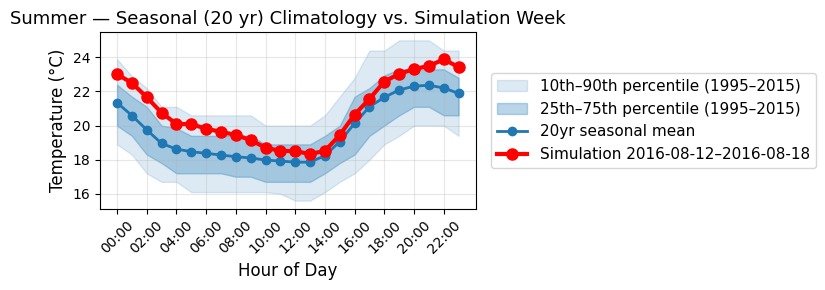

Computing seasonal climatology (winter) for years 1995–2015...
Fetching simulation-week data for winter (2016-12-12–2016-12-18)...


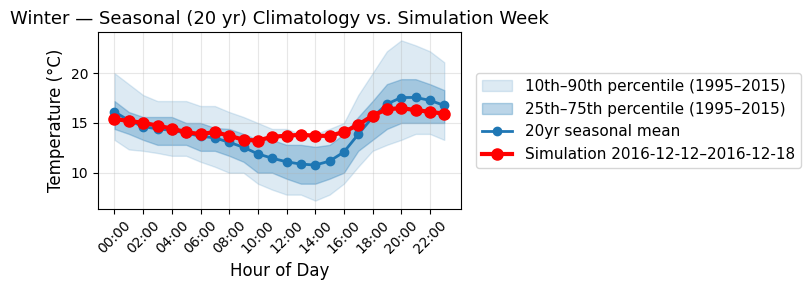

In [171]:
# climatology of correponding season vs. simulation week
yr_start = 1995
yr_end = 2015 
n_years = yr_end - yr_start
years = range(yr_start, yr_end+1) 

def climatology_for_season(station_id, season, years):
    rows = []
    for y in years:
        if season.lower() == 'winter':
            s = datetime(y, 12, 1)
            e = datetime(y + 1, 2, 28)  # Dec (y) + Jan/Feb (y+1)
        elif season.lower() == 'summer':
            s = datetime(y, 6, 1)
            e = datetime(y, 8, 31)
        else:
            raise ValueError("Unknown season: " + str(season))

        try:
            df = ms.hourly(station_id, s, e).fetch()
        except Exception:
            continue
        if df is None or df.empty:
            continue
        df['hour'] = df.index.hour
        rows.append(df[['temp', 'hour']])

    if not rows:
        return None
    all_data = pd.concat(rows, axis=0)
    grouped = all_data.groupby('hour')['temp']

    return {
        'mean': grouped.mean(),
        'p10': grouped.quantile(0.10),
        'p25': grouped.quantile(0.25),
        'p75': grouped.quantile(0.75),
        'p90': grouped.quantile(0.90),
    }

for season, periods in time_periods.items():
    # compute seasonal (JJA or DJF) climatology across years
    print(f"Computing seasonal climatology ({season}) for years {years.start}–{years.stop-1}...")
    clim = climatology_for_season(station_id, season, years)
    if clim is None:
        print(f"No climatology for season {season}; skipping.")
        continue

    # fetch simulation-week hourly means
    sim_start, sim_end = periods['simulation']
    print(f"Fetching simulation-week data for {season} ({sim_start.date()}–{sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    if ts_sim is None or ts_sim.empty:
        print("No simulation-week data; skipping.")
        continue
    ts_sim['hour'] = ts_sim.index.hour
    sim_hourly = ts_sim.groupby('hour')['temp'].mean().reindex(range(24))

    # plot (legend placed to the right)
    hours = np.arange(24)
    fig, ax = plt.subplots(figsize=(8, 3))

    ax.fill_between(hours,
                    clim['p10'].reindex(hours).values,
                    clim['p90'].reindex(hours).values,
                    alpha=0.15, color='C0', label=f'10th–90th percentile ({yr_start}–{yr_end})')
    ax.fill_between(hours,
                    clim['p25'].reindex(hours).values,
                    clim['p75'].reindex(hours).values,
                    alpha=0.30, color='C0', label=f'25th–75th percentile ({yr_start}–{yr_end})')
    ax.plot(hours, clim['mean'].reindex(hours).values, 'o-', color='C0', linewidth=2, markersize=6,
            label=f'{n_years}yr seasonal mean')
    ax.plot(sim_hourly.index.values, sim_hourly.values, 'o-', color='red', linewidth=3, markersize=8,
            label=f'Simulation {sim_start.date()}–{sim_end.date()}')

    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Temperature (°C)', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Seasonal ({n_years} yr) Climatology vs. Simulation Week', fontsize=13)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
    ax.grid(True, alpha=0.3)

    # place legend outside to the right and make room
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    fig.subplots_adjust(right=0.78)

    plt.tight_layout()
    plt.show()

## Wind Speed

Fetching hourly data for summer reference period (2016-08-01 to 2016-08-31)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


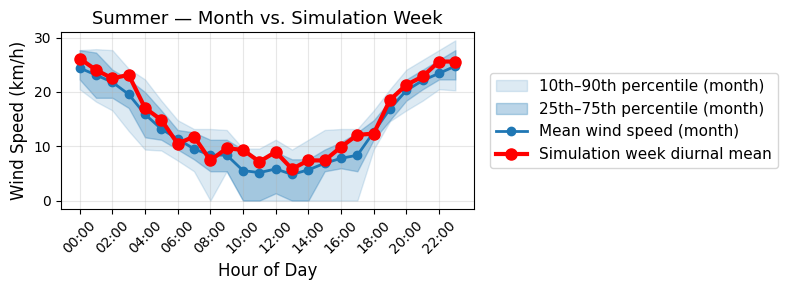

Fetching hourly data for winter reference period (2016-12-01 to 2016-12-31)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


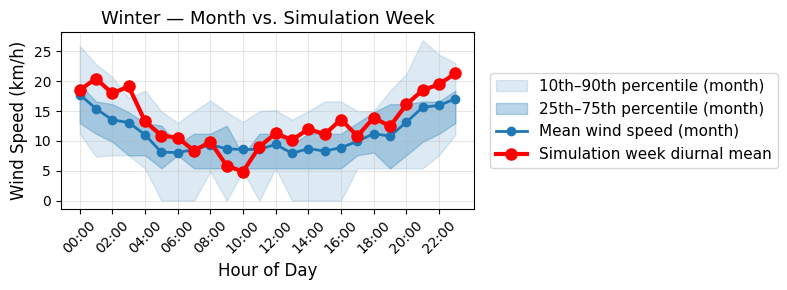

In [173]:
#  Month vs. simulation week
time_periods = {
    'summer': {
        'reference': (datetime(2016, 8, 1), datetime(2016, 8, 31)),
        'simulation': (p2_start, p2_end)
    },
    'winter': {
        'reference': (datetime(2016, 12, 1), datetime(2016, 12, 31)),
        'simulation': (p1_start, p1_end)
    }
}

for season, periods in time_periods.items():
    # Reference (full month)
    ref_start, ref_end = periods['reference']
    print(f"Fetching hourly data for {season} reference period ({ref_start.date()} to {ref_end.date()})...")
    ts_ref = ms.hourly(station_id, ref_start, ref_end).fetch()
    ts_ref['hour'] = ts_ref.index.hour
    ref_hourly = ts_ref.groupby('hour')['wspd'].agg([
        'mean',
        ('p10', lambda x: x.quantile(0.10)),
        ('p25', lambda x: x.quantile(0.25)),
        ('p75', lambda x: x.quantile(0.75)),
        ('p90', lambda x: x.quantile(0.90)),
    ]).reset_index()

    # Simulation week
    sim_start, sim_end = periods['simulation']
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    ts_sim['hour'] = ts_sim.index.hour
    sim_hourly = ts_sim.groupby('hour')['wspd'].mean()

    # Plot
    fig, ax = plt.subplots(figsize=(8, 3))
    hours = ref_hourly['hour'].values
    mean_wspd = ref_hourly['mean'].values
    p10 = ref_hourly['p10'].values
    p25 = ref_hourly['p25'].values
    p75 = ref_hourly['p75'].values
    p90 = ref_hourly['p90'].values

    ax.fill_between(hours, p10, p90, alpha=0.15, color='C0', label='10th–90th percentile (month)')
    ax.fill_between(hours, p25, p75, alpha=0.30, color='C0', label='25th–75th percentile (month)')
    ax.plot(hours, mean_wspd, 'o-', linewidth=2, markersize=6, color='C0', label='Mean wind speed (month)')
    ax.plot(sim_hourly.index, sim_hourly.values, 'o-', linewidth=3, markersize=8, color='red', label='Simulation week diurnal mean')

    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Wind Speed (km/h)', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Month vs. Simulation Week', fontsize=13)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()

Fetching hourly data for summer reference period (2016-06-01 to 2016-08-31)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


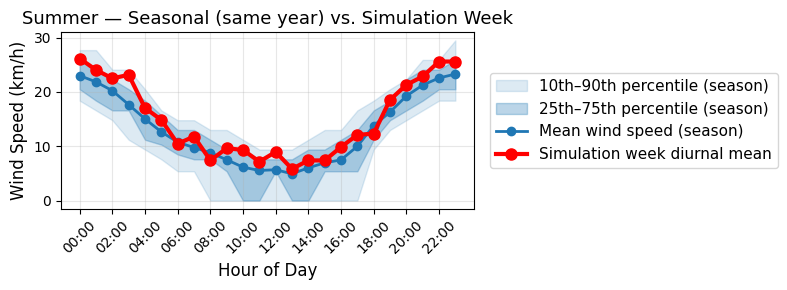

Fetching hourly data for winter reference period (2016-12-01 to 2017-02-28)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


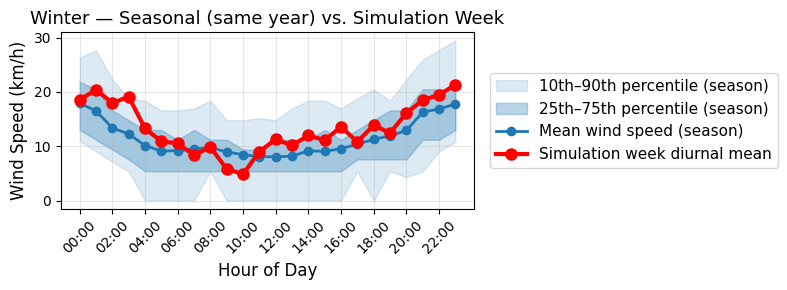

In [174]:
# Seasonal vs. simulation week
time_periods = {
    'summer': {
        'reference': (datetime(2016, 6, 1), datetime(2016, 8, 31)),
        'simulation': (p2_start, p2_end)
    },
    'winter': {
        'reference': (datetime(2016, 12, 1), datetime(2017, 2, 28)),
        'simulation': (p1_start, p1_end)
    }
}

for season, periods in time_periods.items():
    # Reference (full season)
    ref_start, ref_end = periods['reference']
    print(f"Fetching hourly data for {season} reference period ({ref_start.date()} to {ref_end.date()})...")
    ts_ref = ms.hourly(station_id, ref_start, ref_end).fetch()
    ts_ref['hour'] = ts_ref.index.hour
    ref_hourly = ts_ref.groupby('hour')['wspd'].agg([
        'mean',
        ('p10', lambda x: x.quantile(0.10)),
        ('p25', lambda x: x.quantile(0.25)),
        ('p75', lambda x: x.quantile(0.75)),
        ('p90', lambda x: x.quantile(0.90)),
    ]).reset_index()

    # Simulation week
    sim_start, sim_end = periods['simulation']
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    ts_sim['hour'] = ts_sim.index.hour
    sim_hourly = ts_sim.groupby('hour')['wspd'].mean()

    # Plot
    fig, ax = plt.subplots(figsize=(8, 3))
    hours = ref_hourly['hour'].values
    mean_wspd = ref_hourly['mean'].values
    p10 = ref_hourly['p10'].values
    p25 = ref_hourly['p25'].values
    p75 = ref_hourly['p75'].values
    p90 = ref_hourly['p90'].values

    ax.fill_between(hours, p10, p90, alpha=0.15, color='C0', label='10th–90th percentile (season)')
    ax.fill_between(hours, p25, p75, alpha=0.30, color='C0', label='25th–75th percentile (season)')
    ax.plot(hours, mean_wspd, 'o-', linewidth=2, markersize=6, color='C0', label='Mean wind speed (season)')
    ax.plot(sim_hourly.index, sim_hourly.values, 'o-', linewidth=3, markersize=8, color='red', label='Simulation week diurnal mean')

    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Wind Speed (km/h)', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Seasonal (same year) vs. Simulation Week', fontsize=13)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()

Computing 20yr climatology for summer (2016-08-12–2016-08-18)...
Fetching simulation-week data for summer (2016-08-12–2016-08-18)...


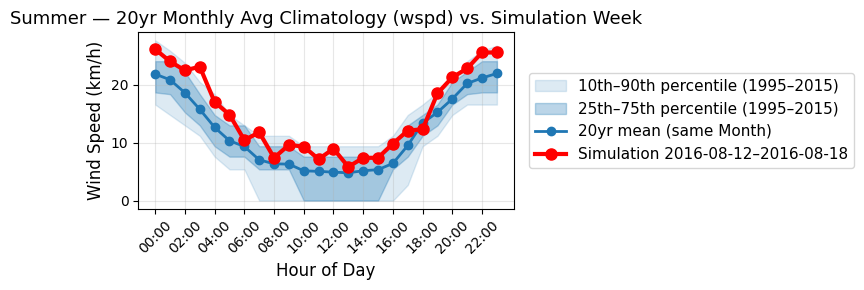

Computing 20yr climatology for winter (2016-12-12–2016-12-18)...
Fetching simulation-week data for winter (2016-12-12–2016-12-18)...


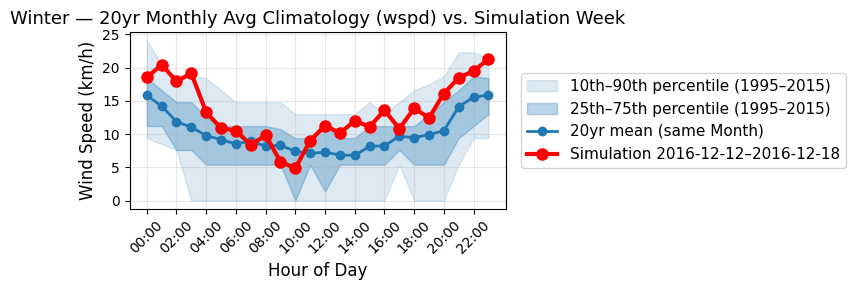

In [193]:
# monthly-window climatology vs. simulation week — WIND SPEED
yr_start = 1995
yr_end = 2015 
n_years = yr_end - yr_start
years = range(yr_start, yr_end+1) 

def climatology_for_month(station_id, start, end, years):
    frames = []
    for y in years:
        try:
            s = start.replace(year=y)
            e = end.replace(year=y)
        except ValueError:
            continue
        df = ms.hourly(station_id, s, e).fetch()
        if df is None or df.empty:
            continue
        df = df.copy()
        df['hour'] = df.index.hour
        frames.append(df[['wspd', 'hour']])
    if not frames:
        return None
    all_data = pd.concat(frames, axis=0)
    grouped = all_data.groupby('hour')['wspd']
    return {
        'mean': grouped.mean(),
        'p10': grouped.quantile(0.10),
        'p25': grouped.quantile(0.25),
        'p75': grouped.quantile(0.75),
        'p90': grouped.quantile(0.90),
    }

for season, periods in time_periods.items():
    sim_start, sim_end = periods['simulation']
    print(f"Computing {n_years}yr climatology for {season} ({sim_start.date()}–{sim_end.date()})...")
    clim = climatology_for_month(station_id, sim_start, sim_end, years)
    if clim is None:
        print("No climatology data available for that window; skipping.")
        continue

    # fetch simulation-week hourly means (wind speed)
    print(f"Fetching simulation-week data for {season} ({sim_start.date()}–{sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    if ts_sim is None or ts_sim.empty:
        print("No simulation-week data; skipping.")
        continue
    ts_sim['hour'] = ts_sim.index.hour
    sim_hourly = ts_sim.groupby('hour')['wspd'].mean().reindex(range(24))

    # plot (legend placed to the right)
    years_label = f"{yr_start}–{yr_end}"
    hours = np.arange(24)
    fig, ax = plt.subplots(figsize=(8, 3))  # wider to make room for legend

    ax.fill_between(hours,
                    clim['p10'].reindex(hours).values,
                    clim['p90'].reindex(hours).values,
                    alpha=0.15, color='C0', label=f'10th–90th percentile ({years_label})')
    ax.fill_between(hours,
                    clim['p25'].reindex(hours).values,
                    clim['p75'].reindex(hours).values,
                    alpha=0.30, color='C0', label=f'25th–75th percentile ({years_label})')
    ax.plot(hours, clim['mean'].reindex(hours).values, 'o-', color='C0', linewidth=2, markersize=6,
            label=f'{n_years}yr mean (same Month)')
    ax.plot(sim_hourly.index.values, sim_hourly.values, 'o-', color='red', linewidth=3, markersize=8,
            label=f'Simulation {sim_start.date()}–{sim_end.date()}')

    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Wind Speed (km/h)', fontsize=12)
    ax.set_title(f'{season.capitalize()} — {n_years}yr Monthly Avg Climatology (wspd) vs. Simulation Week', fontsize=13)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
    ax.grid(True, alpha=0.3)

    # place legend outside to the right and make room
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    fig.subplots_adjust(right=0.78)

    plt.tight_layout()
    plt.show()

Computing seasonal climatology (summer) for years 1995–2015...
Fetching simulation-week data for summer (2016-08-12–2016-08-18)...


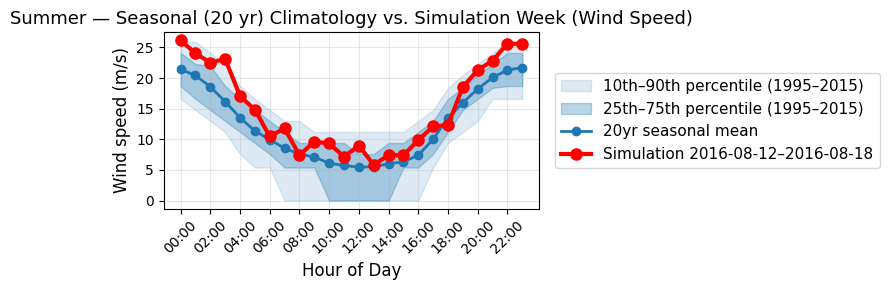

Computing seasonal climatology (winter) for years 1995–2015...
Fetching simulation-week data for winter (2016-12-12–2016-12-18)...


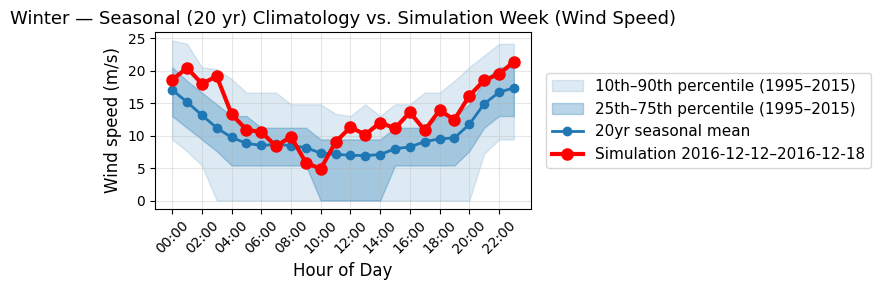

In [176]:
# climatology of corresponding season vs. simulation week
yr_start = 1995
yr_end = 2015
n_years = yr_end - yr_start
years = range(yr_start, yr_end + 1)

def climatology_for_season(station_id, season, years):
    """Percentiles computed over all hourly samples across years, not per-year means."""
    frames = []
    for y in years:
        if season.lower() == 'winter':
            s = datetime(y, 12, 1)
            e = datetime(y + 1, 2, 28)
        elif season.lower() == 'summer':
            s = datetime(y, 6, 1)
            e = datetime(y, 8, 31)
        else:
            raise ValueError("Unknown season: " + str(season))

        try:
            df = ms.hourly(station_id, s, e).fetch()
        except Exception:
            continue
        if df is None or df.empty:
            continue
        df = df.copy()
        df['hour'] = df.index.hour
        frames.append(df[['wspd', 'hour']])

    if not frames:
        return None

    all_data = pd.concat(frames, axis=0)
    grouped = all_data.groupby('hour')['wspd']
    return {
        'mean': grouped.mean(),
        'p10': grouped.quantile(0.10),
        'p25': grouped.quantile(0.25),
        'p75': grouped.quantile(0.75),
        'p90': grouped.quantile(0.90),
    }

for season, periods in time_periods.items():
    # compute seasonal (JJA or DJF) climatology across years
    print(f"Computing seasonal climatology ({season}) for years {years.start}–{years.stop-1}...")
    clim = climatology_for_season(station_id, season, years)
    if clim is None:
        print(f"No climatology for season {season}; skipping.")
        continue

    # fetch simulation-week hourly means
    sim_start, sim_end = periods['simulation']
    print(f"Fetching simulation-week data for {season} ({sim_start.date()}–{sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    if ts_sim is None or ts_sim.empty:
        print("No simulation-week data; skipping.")
        continue
    ts_sim['hour'] = ts_sim.index.hour
    sim_hourly = ts_sim.groupby('hour')['wspd'].mean().reindex(range(24))

    # plot (legend placed to the right)
    hours = np.arange(24)
    fig, ax = plt.subplots(figsize=(8, 3))

    ax.fill_between(hours,
                    clim['p10'].reindex(hours).values,
                    clim['p90'].reindex(hours).values,
                    alpha=0.15, color='C0', label=f'10th–90th percentile ({yr_start}–{yr_end})')
    ax.fill_between(hours,
                    clim['p25'].reindex(hours).values,
                    clim['p75'].reindex(hours).values,
                    alpha=0.30, color='C0', label=f'25th–75th percentile ({yr_start}–{yr_end})')
    ax.plot(hours, clim['mean'].reindex(hours).values, 'o-', color='C0', linewidth=2, markersize=6,
            label=f'{n_years}yr seasonal mean')
    ax.plot(sim_hourly.index.values, sim_hourly.values, 'o-', color='red', linewidth=3, markersize=8,
            label=f'Simulation {sim_start.date()}–{sim_end.date()}')

    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Wind speed (m/s)', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Seasonal ({n_years} yr) Climatology vs. Simulation Week (Wind Speed)', fontsize=13)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
    ax.grid(True, alpha=0.3)

    # place legend outside to the right and make room
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    fig.subplots_adjust(right=0.78)

    plt.tight_layout()
    plt.show()

# Compare Distributions

## Temperature

Fetching hourly data for summer reference period (2016-08-01 to 2016-08-31)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


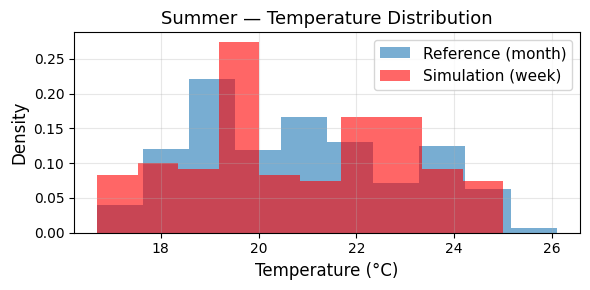

Fetching hourly data for winter reference period (2016-12-01 to 2016-12-31)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


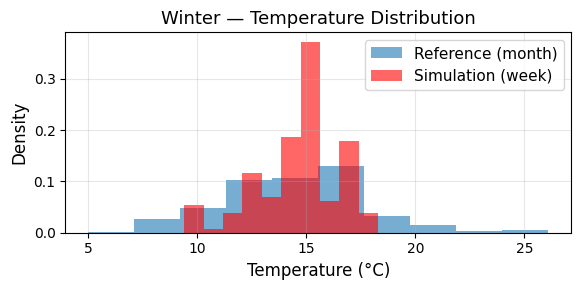

In [180]:
# Month vs. simulation week
time_periods = {
    'summer': {
        'reference': (datetime(2016, 8, 1), datetime(2016, 8, 31)),
        'simulation': (p2_start, p2_end)
    },
    'winter': {
        'reference': (datetime(2016, 12, 1), datetime(2016, 12, 31)),
        'simulation': (p1_start, p1_end)
    }
}

for season, periods in time_periods.items():
    # Reference (full month)
    ref_start, ref_end = periods['reference']
    print(f"Fetching hourly data for {season} reference period ({ref_start.date()} to {ref_end.date()})...")
    ts_ref = ms.hourly(station_id, ref_start, ref_end).fetch()
    ref_temps = ts_ref['temp']

    # Simulation week
    sim_start, sim_end = periods['simulation']
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    sim_temps = ts_sim['temp']

    # Plot histograms
    fig, ax = plt.subplots(figsize=(6, 3))

    ax.hist(ref_temps, alpha=0.6, color='C0', label='Reference (month)', density=True)
    ax.hist(sim_temps, alpha=0.6, color='red', label='Simulation (week)', density=True)

    ax.set_xlabel('Temperature (°C)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Temperature Distribution', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

Fetching hourly data for summer reference period (2016-06-01 to 2016-08-31)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


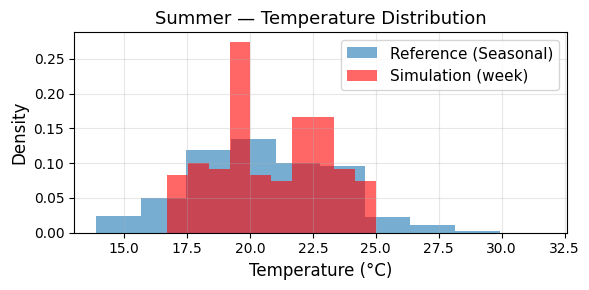

Fetching hourly data for winter reference period (2016-12-01 to 2017-02-28)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


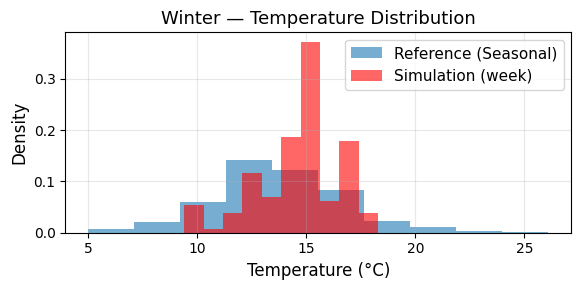

In [181]:
# Seasonal vs. simulation week
time_periods = {
    'summer': {
        'reference': (datetime(2016, 6, 1), datetime(2016, 8, 31)),
        'simulation': (p2_start, p2_end)
    },
    'winter': {
        'reference': (datetime(2016, 12, 1), datetime(2017, 2, 28)),
        'simulation': (p1_start, p1_end)
    }
}

for season, periods in time_periods.items():
    # Reference (full month)
    ref_start, ref_end = periods['reference']
    print(f"Fetching hourly data for {season} reference period ({ref_start.date()} to {ref_end.date()})...")
    ts_ref = ms.hourly(station_id, ref_start, ref_end).fetch()
    ref_temps = ts_ref['temp']

    # Simulation week
    sim_start, sim_end = periods['simulation']
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    sim_temps = ts_sim['temp']

    # Plot histograms
    fig, ax = plt.subplots(figsize=(6, 3))

    ax.hist(ref_temps, alpha=0.6, color='C0', label='Reference (Seasonal)', density=True)
    ax.hist(sim_temps, alpha=0.6, color='red', label='Simulation (week)', density=True)

    ax.set_xlabel('Temperature (°C)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Temperature Distribution', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

Fetching climatological hourly data for summer (August, 1995-2015)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


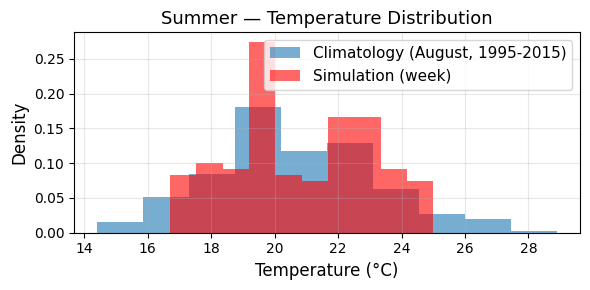

Fetching climatological hourly data for winter (December, 1995-2015)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


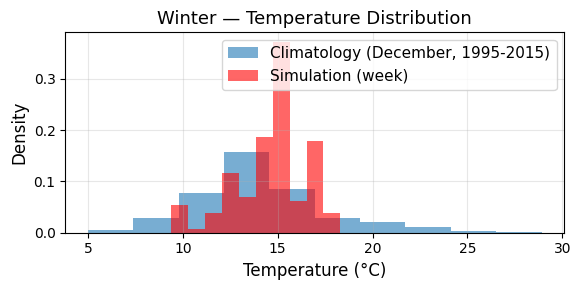

In [185]:
# Climatological month vs. simulation week
yr_start = 1995
yr_end = 2015 
n_years = yr_end - yr_start
years = range(yr_start, yr_end+1) 

def get_climatology_hourly(station_id, start, end, years):
    rows = []
    for y in years:
        try:
            s = start.replace(year=y)
            e = end.replace(year=y)
        except ValueError:
            # skip invalid dates (e.g. Feb 29 on non-leap years)
            continue
        df = ms.hourly(station_id, s, e).fetch()
        if df is None or df.empty:
            continue
        df['hour'] = df.index.hour
        rows.append(df[['temp', 'hour']])

    if not rows:
        return None
    all_data = pd.concat(rows, axis=0)
    return all_data

for season, periods in time_periods.items():
    # Reference (climatological month across all years)
    sim_start, sim_end = periods['simulation']
    print(f"Fetching climatological hourly data for {season} ({sim_start.strftime('%B')}, {yr_start}-{yr_end})...")
    clim_data = get_climatology_hourly(station_id, sim_start, sim_end, years)
    if clim_data is None:
        print("No climatology data available for that window; skipping.")
        continue
    clim_temps = clim_data['temp']

    # Simulation week
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    sim_temps = ts_sim['temp']

    # Plot histograms
    fig, ax = plt.subplots(figsize=(6, 3))

    ax.hist(clim_temps, alpha=0.6, color='C0', label=f'Climatology ({sim_start.strftime("%B")}, {yr_start}-{yr_end})', density=True)
    ax.hist(sim_temps, alpha=0.6, color='red', label='Simulation (week)', density=True)

    ax.set_xlabel('Temperature (°C)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Temperature Distribution', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

Fetching climatological hourly data for summer (Seasonal, 1995-2015)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


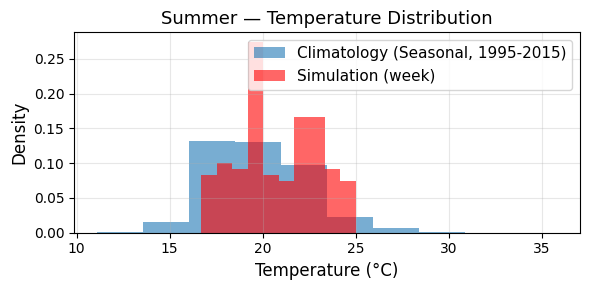

Fetching climatological hourly data for winter (Seasonal, 1995-2015)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


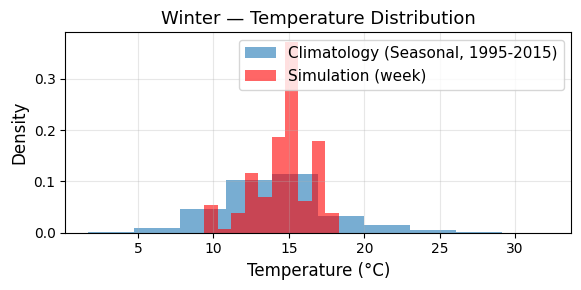

In [187]:
# Climatological season vs. simulation week
yr_start = 1995
yr_end = 2015 
n_years = yr_end - yr_start
years = range(yr_start, yr_end+1) 

def get_climatology_seasonal(station_id, season, years):
    rows = []
    for y in years:
        if season.lower() == 'winter':
            s = datetime(y, 12, 1)
            e = datetime(y + 1, 2, 28)  # Dec (y) + Jan/Feb (y+1)
        elif season.lower() == 'summer':
            s = datetime(y, 6, 1)
            e = datetime(y, 8, 31)
        else:
            raise ValueError("Unknown season: " + str(season))

        try:
            df = ms.hourly(station_id, s, e).fetch()
        except Exception:
            continue
        if df is None or df.empty:
            continue
        df['hour'] = df.index.hour
        rows.append(df[['temp', 'hour']])

    if not rows:
        return None
    all_data = pd.concat(rows, axis=0)
    return all_data

for season, periods in time_periods.items():
    # Reference (climatological month across all years)
    sim_start, sim_end = periods['simulation']
    print(f"Fetching climatological hourly data for {season} (Seasonal, {yr_start}-{yr_end})...")
    clim_data = get_climatology_seasonal(station_id, season, years)
    if clim_data is None:
        print("No climatology data available for that window; skipping.")
        continue
    clim_temps = clim_data['temp']

    # Simulation week
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    sim_temps = ts_sim['temp']

    # Plot histograms
    fig, ax = plt.subplots(figsize=(6, 3))

    ax.hist(clim_temps, alpha=0.6, color='C0', label=f'Climatology (Seasonal, {yr_start}-{yr_end})', density=True)
    ax.hist(sim_temps, alpha=0.6, color='red', label='Simulation (week)', density=True)

    ax.set_xlabel('Temperature (°C)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Temperature Distribution', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

## Wind Speed

Fetching hourly data for summer reference period (2016-08-01 to 2016-08-31)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


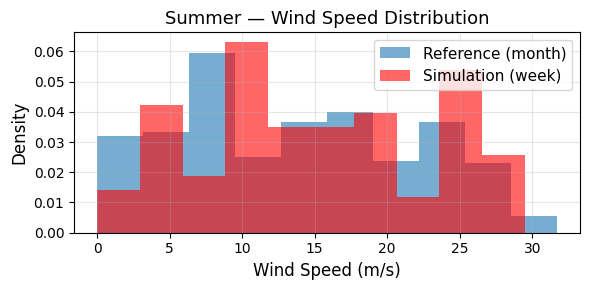

Fetching hourly data for winter reference period (2016-12-01 to 2016-12-31)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


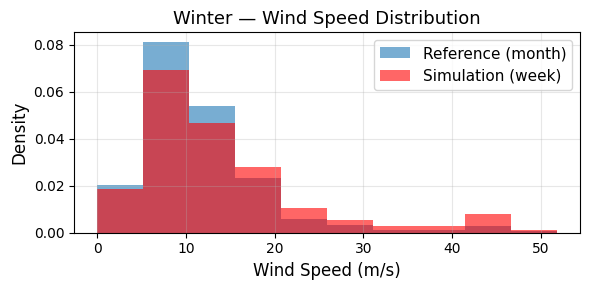

In [188]:
# Month vs. simulation week
time_periods = {
    'summer': {
        'reference': (datetime(2016, 8, 1), datetime(2016, 8, 31)),
        'simulation': (p2_start, p2_end)
    },
    'winter': {
        'reference': (datetime(2016, 12, 1), datetime(2016, 12, 31)),
        'simulation': (p1_start, p1_end)
    }
}

for season, periods in time_periods.items():
    # Reference (full month)
    ref_start, ref_end = periods['reference']
    print(f"Fetching hourly data for {season} reference period ({ref_start.date()} to {ref_end.date()})...")
    ts_ref = ms.hourly(station_id, ref_start, ref_end).fetch()
    ref_temps = ts_ref['wspd']

    # Simulation week
    sim_start, sim_end = periods['simulation']
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    sim_temps = ts_sim['wspd']

    # Plot histograms
    fig, ax = plt.subplots(figsize=(6, 3))

    ax.hist(ref_temps, alpha=0.6, color='C0', label='Reference (month)', density=True)
    ax.hist(sim_temps, alpha=0.6, color='red', label='Simulation (week)', density=True)

    ax.set_xlabel('Wind Speed (m/s)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Wind Speed Distribution', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

Fetching hourly data for summer reference period (2016-06-01 to 2016-08-31)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


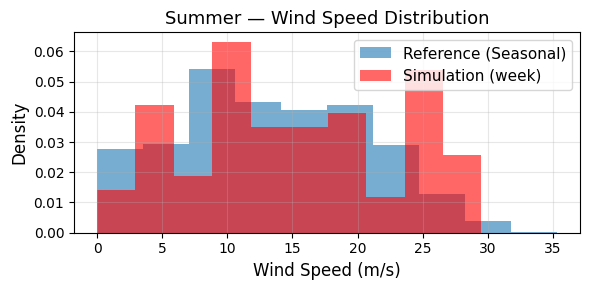

Fetching hourly data for winter reference period (2016-12-01 to 2017-02-28)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


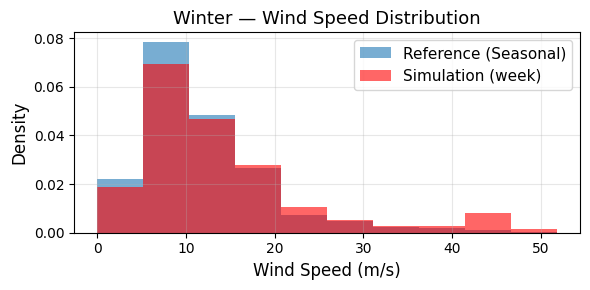

In [189]:
# Seasonal vs. simulation week
time_periods = {
    'summer': {
        'reference': (datetime(2016, 6, 1), datetime(2016, 8, 31)),
        'simulation': (p2_start, p2_end)
    },
    'winter': {
        'reference': (datetime(2016, 12, 1), datetime(2017, 2, 28)),
        'simulation': (p1_start, p1_end)
    }
}

for season, periods in time_periods.items():
    # Reference (full month)
    ref_start, ref_end = periods['reference']
    print(f"Fetching hourly data for {season} reference period ({ref_start.date()} to {ref_end.date()})...")
    ts_ref = ms.hourly(station_id, ref_start, ref_end).fetch()
    ref_temps = ts_ref['wspd']

    # Simulation week
    sim_start, sim_end = periods['simulation']
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    sim_temps = ts_sim['wspd']

    # Plot histograms
    fig, ax = plt.subplots(figsize=(6, 3))

    ax.hist(ref_temps, alpha=0.6, color='C0', label='Reference (Seasonal)', density=True)
    ax.hist(sim_temps, alpha=0.6, color='red', label='Simulation (week)', density=True)

    ax.set_xlabel('Wind Speed (m/s)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Wind Speed Distribution', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

Fetching climatological hourly data for summer (August, 1995-2015)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


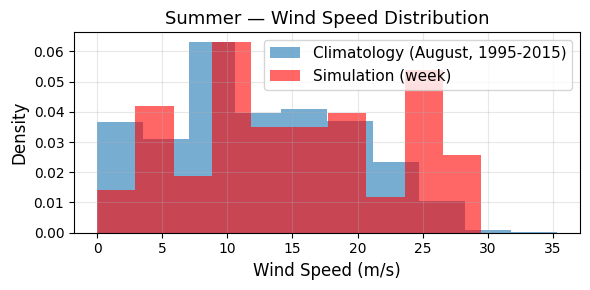

Fetching climatological hourly data for winter (December, 1995-2015)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


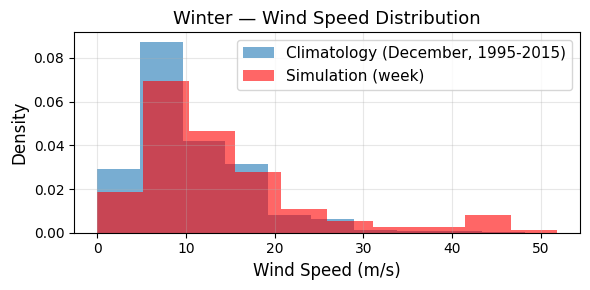

In [190]:
# Climatological month vs. simulation week
yr_start = 1995
yr_end = 2015 
n_years = yr_end - yr_start
years = range(yr_start, yr_end+1) 

def get_climatology_hourly(station_id, start, end, years):
    rows = []
    for y in years:
        try:
            s = start.replace(year=y)
            e = end.replace(year=y)
        except ValueError:
            # skip invalid dates (e.g. Feb 29 on non-leap years)
            continue
        df = ms.hourly(station_id, s, e).fetch()
        if df is None or df.empty:
            continue
        df['hour'] = df.index.hour
        rows.append(df[['wspd', 'hour']])

    if not rows:
        return None
    all_data = pd.concat(rows, axis=0)
    return all_data

for season, periods in time_periods.items():
    # Reference (climatological month across all years)
    sim_start, sim_end = periods['simulation']
    print(f"Fetching climatological hourly data for {season} ({sim_start.strftime('%B')}, {yr_start}-{yr_end})...")
    clim_data = get_climatology_hourly(station_id, sim_start, sim_end, years)
    if clim_data is None:
        print("No climatology data available for that window; skipping.")
        continue
    clim_temps = clim_data['wspd']

    # Simulation week
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    sim_temps = ts_sim['wspd']

    # Plot histograms
    fig, ax = plt.subplots(figsize=(6, 3))

    ax.hist(clim_temps, alpha=0.6, color='C0', label=f'Climatology ({sim_start.strftime("%B")}, {yr_start}-{yr_end})', density=True)
    ax.hist(sim_temps, alpha=0.6, color='red', label='Simulation (week)', density=True)

    ax.set_xlabel('Wind Speed (m/s)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Wind Speed Distribution', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

Fetching climatological hourly data for summer (Seasonal, 1995-2015)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


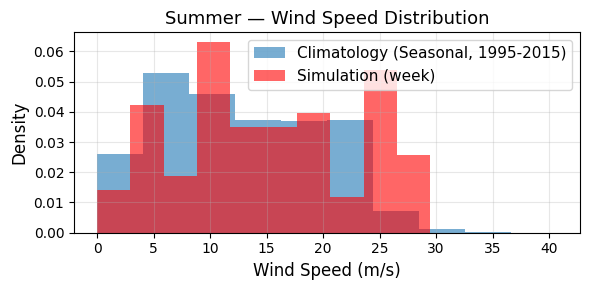

Fetching climatological hourly data for winter (Seasonal, 1995-2015)...
Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...


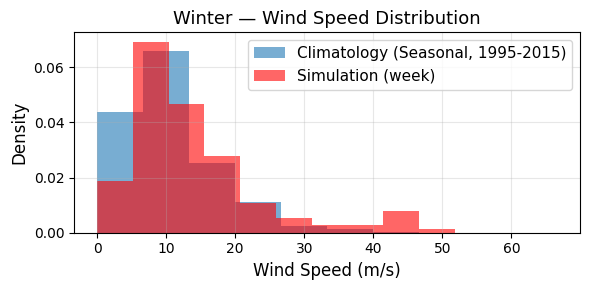

In [191]:
# Climatological season vs. simulation week
yr_start = 1995
yr_end = 2015 
n_years = yr_end - yr_start
years = range(yr_start, yr_end+1) 

def get_climatology_seasonal(station_id, season, years):
    rows = []
    for y in years:
        if season.lower() == 'winter':
            s = datetime(y, 12, 1)
            e = datetime(y + 1, 2, 28)  # Dec (y) + Jan/Feb (y+1)
        elif season.lower() == 'summer':
            s = datetime(y, 6, 1)
            e = datetime(y, 8, 31)
        else:
            raise ValueError("Unknown season: " + str(season))

        try:
            df = ms.hourly(station_id, s, e).fetch()
        except Exception:
            continue
        if df is None or df.empty:
            continue
        df['hour'] = df.index.hour
        rows.append(df[['wspd', 'hour']])

    if not rows:
        return None
    all_data = pd.concat(rows, axis=0)
    return all_data

for season, periods in time_periods.items():
    # Reference (climatological month across all years)
    sim_start, sim_end = periods['simulation']
    print(f"Fetching climatological hourly data for {season} (Seasonal, {yr_start}-{yr_end})...")
    clim_data = get_climatology_seasonal(station_id, season, years)
    if clim_data is None:
        print("No climatology data available for that window; skipping.")
        continue
    clim_temps = clim_data['wspd']

    # Simulation week
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")
    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    sim_temps = ts_sim['wspd']

    # Plot histograms
    fig, ax = plt.subplots(figsize=(6, 3))

    ax.hist(clim_temps, alpha=0.6, color='C0', label=f'Climatology (Seasonal, {yr_start}-{yr_end})', density=True)
    ax.hist(sim_temps, alpha=0.6, color='red', label='Simulation (week)', density=True)

    ax.set_xlabel('Wind Speed (m/s)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{season.capitalize()} — Wind Speed Distribution', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# Diagnosing differences in ΔΤ Sensitivities to AHF

Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


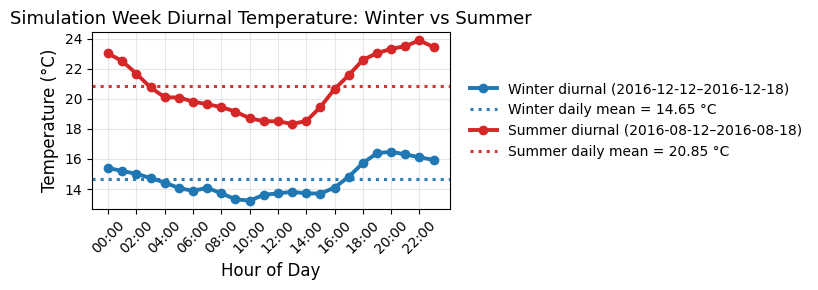

In [200]:
# plot the diurnal cycle of T for winter vs. summer simulation periods 
colors = {"winter": "tab:blue", "summer": "tab:red"}
order = ["winter", "summer"]  # force consistent order

fig, ax = plt.subplots(figsize=(8, 3))

for season in order:
    if season not in time_periods:
        continue

    sim_start, sim_end = time_periods[season]["simulation"]
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")

    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    if ts_sim is None or ts_sim.empty:
        print(f"No data for {season}; skipping.")
        continue

    ts_sim = ts_sim.copy()
    ts_sim["hour"] = ts_sim.index.hour

    # Diurnal cycle (hourly mean over simulation week)
    sim_hourly = ts_sim.groupby("hour")["temp"].mean().reindex(range(24))

    # Daily mean (single value over all hours in simulation week)
    daily_mean = ts_sim["temp"].mean()

    # Main diurnal curve
    ax.plot(
        sim_hourly.index.values,
        sim_hourly.values,
        "o-",
        color=colors[season],
        linewidth=2.8,
        markersize=6,
        label=f"{season.capitalize()} diurnal ({sim_start.date()}–{sim_end.date()})",
    )

    # Dotted daily mean line
    ax.axhline(
        daily_mean,
        color=colors[season],
        linestyle=":",
        linewidth=2.2,
        alpha=0.95,
        label=f"{season.capitalize()} daily mean = {daily_mean:.2f} °C",
    )

ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("Temperature (°C)", fontsize=12)
ax.set_title("Simulation Week Diurnal Temperature: Winter vs Summer", fontsize=13)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], rotation=45)
ax.grid(True, alpha=0.3)

# cleaner legend placement
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=False)
fig.subplots_adjust(right=0.74)

plt.tight_layout()
plt.show()

Fetching hourly data for winter simulation period (2016-12-12 to 2016-12-18)...
Fetching hourly data for summer simulation period (2016-08-12 to 2016-08-18)...


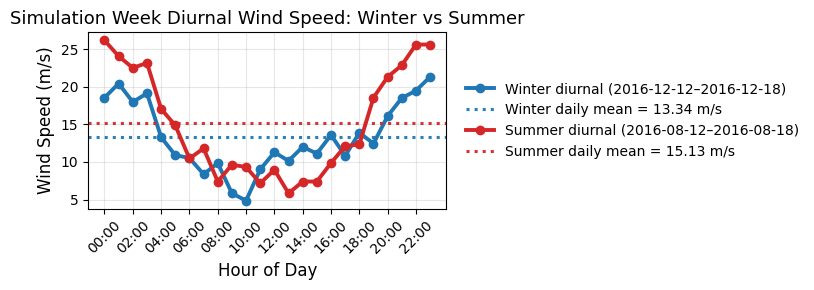

In [ ]:
# plot the diurnal cycle of WS for winter vs. summer simulation periods 
colors = {"winter": "tab:blue", "summer": "tab:red"}
order = ["winter", "summer"]  # force consistent order

fig, ax = plt.subplots(figsize=(8, 3))

for season in order:
    if season not in time_periods:
        continue

    sim_start, sim_end = time_periods[season]["simulation"]
    print(f"Fetching hourly data for {season} simulation period ({sim_start.date()} to {sim_end.date()})...")

    ts_sim = ms.hourly(station_id, sim_start, sim_end).fetch()
    if ts_sim is None or ts_sim.empty:
        print(f"No data for {season}; skipping.")
        continue

    ts_sim = ts_sim.copy()
    ts_sim["hour"] = ts_sim.index.hour

    # Diurnal cycle (hourly mean over simulation week)
    sim_hourly = ts_sim.groupby("hour")["wspd"].mean().reindex(range(24))

    # Daily mean (single value over all hours in simulation week)
    daily_mean = ts_sim["wspd"].mean()

    # Main diurnal curve
    ax.plot(
        sim_hourly.index.values,
        sim_hourly.values,
        "o-",
        color=colors[season],
        linewidth=2.8,
        markersize=6,
        label=f"{season.capitalize()} diurnal ({sim_start.date()}–{sim_end.date()})",
    )

    # Dotted daily mean line
    ax.axhline(
        daily_mean,
        color=colors[season],
        linestyle=":",
        linewidth=2.2,
        alpha=0.95,
        label=f"{season.capitalize()} daily mean = {daily_mean:.2f} m/s",
    )

ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("Wind Speed (m/s)", fontsize=12)
ax.set_title("Simulation Week Diurnal Wind Speed: Winter vs Summer", fontsize=13)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], rotation=45)
ax.grid(True, alpha=0.3)

# cleaner legend placement
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=False)
fig.subplots_adjust(right=0.74)

plt.tight_layout()
plt.show()